# Setup and Context

### Introduction

On November 27, 1895, Alfred Nobel signed his last will in Paris. When it was opened after his death, the will caused a lot of controversy, as Nobel had left much of his wealth for the establishment of a prize.

Alfred Nobel dictates that his entire remaining estate should be used to endow “prizes to those who, during the preceding year, have conferred the greatest benefit to humankind”.

Every year the Nobel Prize is given to scientists and scholars in the categories chemistry, literature, physics, physiology or medicine, economics, and peace. 

<img src=https://i.imgur.com/36pCx5Q.jpg>
<img src="./image_1.jpg">

Let's see what patterns we can find in the data of the past Nobel laureates. What can we learn about the Nobel prize and our world more generally?

### Upgrade plotly (only Google Colab Notebook)

Google Colab may not be running the latest version of plotly. If you're working in Google Colab, uncomment the line below, run the cell, and restart your notebook server. 

In [191]:
# %pip install --upgrade plotly

### Import Statements

In [192]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Notebook Presentation

In [193]:
pd.options.display.float_format = '{:_.2f}'.format

### Read the Data

In [194]:
df_data = pd.read_csv('nobel_prize_data.csv')

Caveats: The exact birth dates for Michael Houghton, Venkatraman Ramakrishnan, and Nadia Murad are unknown. I've substituted them with mid-year estimate of July 2nd. 


# Data Exploration & Cleaning

**Challenge**: Preliminary data exploration. 
* What is the shape of `df_data`? How many rows and columns?
* What are the column names?
* In which year was the Nobel prize first awarded?
* Which year is the latest year included in the dataset?

In [195]:
print(f'Our dataset has {df_data.shape[0]} rows and {df_data.shape[1]} columns')


Our dataset has 962 rows and 16 columns


In [196]:
df_data.columns

Index(['year', 'category', 'prize', 'motivation', 'prize_share',
       'laureate_type', 'full_name', 'birth_date', 'birth_city',
       'birth_country', 'birth_country_current', 'sex', 'organization_name',
       'organization_city', 'organization_country', 'ISO'],
      dtype='str')

In [197]:
print(f'First Nobel prize was awarded in: {df_data.year.min().item()} year')

First Nobel prize was awarded in: 1901 year


In [198]:
print(f'Last year included in the dataset is: {df_data.year.max().item()}')

Last year included in the dataset is: 2020


**Challange**: 
* Are there any duplicate values in the dataset?
* Are there NaN values in the dataset?
* Which columns tend to have NaN values?
* How many NaN values are there per column? 
* Why do these columns have NaN values?  

### Check for Duplicates

In [199]:
pd.options.display.float_format = '{:_.2f}'.format
df_data.describe()
df_data.duplicated().values.any()

np.False_

In [200]:
df_data.isna().any()

year                     False
category                 False
prize                    False
motivation                True
prize_share              False
laureate_type            False
full_name                False
birth_date                True
birth_city                True
birth_country             True
birth_country_current     True
sex                       True
organization_name         True
organization_city         True
organization_country      True
ISO                       True
dtype: bool

In [201]:
# df_data[['motivation','sex']].isna().value_counts()
# df_data[['motivation']].isna().value_counts()
series = df_data.isna().sum()
for _, __ in series.items():
  if __ != 0:
    print(_, __)


motivation 88
birth_date 28
birth_city 31
birth_country 28
birth_country_current 28
sex 28
organization_name 255
organization_city 255
organization_country 254
ISO 28


### Check for NaN Values

In [202]:
df_data.isna()

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False,True,True,True,False
4,False,False,False,True,False,False,False,False,False,False,False,False,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
957,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
958,False,False,False,False,False,False,False,True,True,True,True,True,True,True,True,True
959,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
960,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [203]:
df_data.isna().any()

year                     False
category                 False
prize                    False
motivation                True
prize_share              False
laureate_type            False
full_name                False
birth_date                True
birth_city                True
birth_country             True
birth_country_current     True
sex                       True
organization_name         True
organization_city         True
organization_country      True
ISO                       True
dtype: bool

In [204]:
df_data.isna().sum()

year                       0
category                   0
prize                      0
motivation                88
prize_share                0
laureate_type              0
full_name                  0
birth_date                28
birth_city                31
birth_country             28
birth_country_current     28
sex                       28
organization_name        255
organization_city        255
organization_country     254
ISO                       28
dtype: int64

In [205]:
for idx, val in df_data.isna().sum().items():
  if val != 0:
    print(idx, val)

motivation 88
birth_date 28
birth_city 31
birth_country 28
birth_country_current 28
sex 28
organization_name 255
organization_city 255
organization_country 254
ISO 28


In [206]:
col_subset = ['year','category','laureate_type','birth_date','full_name','organization_name']
df_data.loc[df_data.birth_date.isna()][col_subset].head(10)

,year,category,laureate_type,birth_date,full_name,organization_name
24,1904,Peace,Organization,NaN,Institut de droit international (Institute of ...,NaN
60,1910,Peace,Organization,NaN,Bureau international permanent de la Paix (Per...,NaN
89,1917,Peace,Organization,NaN,Comité international de la Croix Rouge (Intern...,NaN
200,1938,Peace,Organization,NaN,Office international Nansen pour les Réfugiés ...,NaN
215,1944,Peace,Organization,NaN,Comité international de la Croix Rouge (Intern...,NaN
237,1947,Peace,Organization,NaN,American Friends Service Committee (The Quakers),NaN
238,1947,Peace,Organization,NaN,Friends Service Council (The Quakers),NaN
283,1954,Peace,Organization,NaN,Office of the United Nations High Commissioner...,NaN
348,1963,Peace,Organization,NaN,Comité international de la Croix Rouge (Intern...,NaN
349,1963,Peace,Organization,NaN,Ligue des Sociétés de la Croix-Rouge (League o...,NaN


In [207]:
col_subset = ['year','category', 'laureate_type','full_name', 'organization_name']
df_data.loc[df_data.organization_name.isna()][col_subset].head()

,year,category,laureate_type,full_name,organization_name
1,1901,Literature,Individual,Sully Prudhomme,NaN
3,1901,Peace,Individual,Frédéric Passy,NaN
4,1901,Peace,Individual,Jean Henry Dunant,NaN
7,1902,Literature,Individual,Christian Matthias Theodor Mommsen,NaN
9,1902,Peace,Individual,Charles Albert Gobat,NaN


### Type Conversions

**Challenge**: 
* Convert the `birth_date` column to Pandas `Datetime` objects
* Add a Column called `share_pct` which has the laureates' share as a percentage in the form of a floating-point number.

#### Convert Year and Birth Date to Datetime

In [208]:
df_data.head()
df_data.birth_date.isna().sum()
df_data.birth_date = pd.to_datetime(df_data.birth_date)
# df_data.year = pd.to_datetime(df_data.year.astype(int), format = 'ISO8601').dt.year # you get int32 no pd.datetime xD
df_data.year = pd.to_datetime(df_data.year.astype(str))
# df_data.year = pd.to_datetime(df_data.year.astype(str)).dt.year
df_data.head()

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO
0,1901-01-01,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Netherlands,Male,Berlin University,Berlin,Germany,NLD
1,1901-01-01,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,Individual,Sully Prudhomme,1839-03-16,Paris,France,France,Male,NaN,NaN,NaN,FRA
2,1901-01-01,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Poland,Male,Marburg University,Marburg,Germany,POL
3,1901-01-01,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Frédéric Passy,1822-05-20,Paris,France,France,Male,NaN,NaN,NaN,FRA
4,1901-01-01,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Switzerland,Male,NaN,NaN,NaN,CHE


In [209]:
df_data[['birth_date','year']].dtypes

birth_date    datetime64[us]
year          datetime64[us]
dtype: object

#### Add a Column with the Prize Share as a Percentage

In [210]:
import pandas
df_data.head(n=5)
a = df_data.prize_share.str.split('/').str[0].astype(float)
b = df_data.prize_share.str.split('/').str[1].astype(float)
df_data['share_pct'] = (a / b) * 100
try:
    df_data = df_data.drop(columns='prize_pct')
except KeyError as ke:
  pass
df_data.head(5)

"""
separated_values = df_data.prize_share.str.split('/', expand=True)
numerator = pd.to_numeric(separated_values[0])
denomenator = pd.to_numeric(separated_values[1])
df_data['share_pct'] = numerator / denomenator
"""



"\nseparated_values = df_data.prize_share.str.split('/', expand=True)\nnumerator = pd.to_numeric(separated_values[0])\ndenomenator = pd.to_numeric(separated_values[1])\ndf_data['share_pct'] = numerator / denomenator\n"

In [211]:
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   year                   962 non-null    datetime64[us]
 1   category               962 non-null    str           
 2   prize                  962 non-null    str           
 3   motivation             874 non-null    str           
 4   prize_share            962 non-null    str           
 5   laureate_type          962 non-null    str           
 6   full_name              962 non-null    str           
 7   birth_date             934 non-null    datetime64[us]
 8   birth_city             931 non-null    str           
 9   birth_country          934 non-null    str           
 10  birth_country_current  934 non-null    str           
 11  sex                    934 non-null    str           
 12  organization_name      707 non-null    str           
 13  organization_cit

# Plotly Donut Chart: Percentage of Male vs. Female Laureates

**Challenge**: Create a [donut chart using plotly](https://plotly.com/python/pie-charts/) which shows how many prizes went to men compared to how many prizes went to women. What percentage of all the prizes went to women?

In [212]:
import plotly.express as px
# sex_counts = df_data['sex'].value_counts()
# fig = px.pie(names=sex_counts.index, values=sex_counts.values)
# fig.show()
x = df_data.loc[df_data.sex == 'Male']['sex'].count()
y = df_data.loc[df_data.sex == 'Female']['sex'].count()
fig = px.pie(df_data, names=['Male','Female'], values=[x,y], title='Nobel prizes awarded by sex', hole=0.2)
fig.show()

In [213]:
biology = df_data.sex.value_counts()
fig = px.pie(labels=biology.index,
             values=biology.values,
             names=biology.index,
             title='Percentage of Male vs. Female Winners',
             hole=0.4,)
fig.update_traces(textposition='inside', textfont_size=15,
                  textinfo='percent')
fig.show()


In [214]:
cat_count = df_data.category.value_counts()
fig = px.pie(names=cat_count.index, values=cat_count.values, title='Number of Nobel prizes per category')
fig.show()

# Who were the first 3 Women to Win the Nobel Prize?

**Challenge**: 
* What are the names of the first 3 female Nobel laureates? 
* What did the win the prize for? 
* What do you see in their `birth_country`? Were they part of an organisation?

In [215]:
df_data.loc[df_data.sex == 'Female'][['full_name','birth_country_current']].head(n=3)

,full_name,birth_country_current
18,"Marie Curie, née Sklodowska",Poland
29,"Baroness Bertha Sophie Felicita von Suttner, n...",Czech Republic
51,Selma Ottilia Lovisa Lagerlöf,Sweden


In [216]:
df_data.head(n=1)
col_sub = ['full_name','birth_country_current','category']
df_data.loc[df_data.sex == 'Female'][col_sub].head(n=3)
df_data.loc[df_data.sex == 'Female'].head(n=3)

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
18,1903-01-01,Physics,The Nobel Prize in Physics 1903,"""in recognition of the extraordinary services ...",1/4,Individual,"Marie Curie, née Sklodowska",1867-11-07,Warsaw,Russian Empire (Poland),Poland,Female,NaN,NaN,NaN,POL,25.00
29,1905-01-01,Peace,The Nobel Peace Prize 1905,NaN,1/1,Individual,"Baroness Bertha Sophie Felicita von Suttner, n...",1843-06-09,Prague,Austrian Empire (Czech Republic),Czech Republic,Female,NaN,NaN,NaN,CZE,100.00
51,1909-01-01,Literature,The Nobel Prize in Literature 1909,"""in appreciation of the lofty idealism, vivid ...",1/1,Individual,Selma Ottilia Lovisa Lagerlöf,1858-11-20,Mårbacka,Sweden,Sweden,Female,NaN,NaN,NaN,SWE,100.00


# Find the Repeat Winners

**Challenge**: Did some people get a Nobel Prize more than once? If so, who were they? 

In [217]:
df_data.full_name.duplicated(keep=False).values.any()
col_sub = ['full_name']
repeat_winners = df_data.loc[df_data.full_name.duplicated(keep=False).values][col_sub].value_counts()
repeat_winners

full_name                                                                        
Comité international de la Croix Rouge (International Committee of the Red Cross)    3
Marie Curie, née Sklodowska                                                          2
Linus Carl Pauling                                                                   2
Office of the United Nations High Commissioner for Refugees (UNHCR)                  2
John Bardeen                                                                         2
Frederick Sanger                                                                     2
Name: count, dtype: int64

In [218]:
is_winner = df_data.duplicated(subset=['full_name'], keep=False)
multiple_winners = df_data.loc[is_winner]
print(f'There are {multiple_winners.full_name.nunique()}'
      f' winners who were awarded the prize more than once.')


There are 6 winners who were awarded the prize more than once.


In [219]:
col_subset = ['year', 'category', 'laureate_type', 'full_name']
multiple_winners[col_subset]

,year,category,laureate_type,full_name
18,1903-01-01,Physics,Individual,"Marie Curie, née Sklodowska"
62,1911-01-01,Chemistry,Individual,"Marie Curie, née Sklodowska"
89,1917-01-01,Peace,Organization,Comité international de la Croix Rouge (Intern...
215,1944-01-01,Peace,Organization,Comité international de la Croix Rouge (Intern...
278,1954-01-01,Chemistry,Individual,Linus Carl Pauling
283,1954-01-01,Peace,Organization,Office of the United Nations High Commissioner...
297,1956-01-01,Physics,Individual,John Bardeen
306,1958-01-01,Chemistry,Individual,Frederick Sanger
340,1962-01-01,Peace,Individual,Linus Carl Pauling
348,1963-01-01,Peace,Organization,Comité international de la Croix Rouge (Intern...


In [220]:
cat_count = df_data.category.value_counts()
cat_count

category
Medicine      222
Physics       216
Chemistry     186
Peace         135
Literature    117
Economics      86
Name: count, dtype: int64

# Number of Prizes per Category

**Challenge**: 
* In how many categories are prizes awarded? 
* Create a plotly bar chart with the number of prizes awarded by category. 
* Use the color scale called `Aggrnyl` to colour the chart, but don't show a color axis.
* Which category has the most number of prizes awarded? 
* Which category has the fewest number of prizes awarded?

In [221]:
df_data.category.nunique()

6

In [222]:
prizes_per_category = df_data.category.value_counts()

v_bar = px.bar(
  x = prizes_per_category.index,
  y = prizes_per_category.values,
  color = prizes_per_category.values,
  color_continuous_scale = 'Aggrnyl',
  title = 'Number of Prizes Awarded per Category',
)

v_bar.update_layout(
  xaxis_title = 'Nobel Prize Category',
  yaxis_title = 'Number of Prizes',
  coloraxis_showscale = False
)

v_bar.show()

In [223]:
df_data.loc[df_data.category == 'Economics'].sort_values(by='year')[:3]

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
393,1969-01-01,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for having developed and applied dynamic mode...",1/2,Individual,Jan Tinbergen,1903-04-12,the Hague,Netherlands,Netherlands,Male,The Netherlands School of Economics,Rotterdam,Netherlands,NLD,50.00
394,1969-01-01,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for having developed and applied dynamic mode...",1/2,Individual,Ragnar Frisch,1895-03-03,Oslo,Norway,Norway,Male,University of Oslo,Oslo,Norway,NOR,50.00
402,1970-01-01,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for the scientific work through which he has ...",1/1,Individual,Paul A. Samuelson,1915-05-15,"Gary, IN",United States of America,United States of America,Male,Massachusetts Institute of Technology (MIT),"Cambridge, MA",United States of America,USA,100.00


In [224]:
cat_men_women = df_data.groupby(['category', 'sex'],
                                as_index=False).aggregate({'prize': pd.Series.count})
cat_men_women.sort_values(by='prize', ascending=False, inplace=True)
cat_men_women

,category,sex,prize
11,Physics,Male,212
7,Medicine,Male,210
1,Chemistry,Male,179
5,Literature,Male,101
9,Peace,Male,90
3,Economics,Male,84
8,Peace,Female,17
4,Literature,Female,16
6,Medicine,Female,12
0,Chemistry,Female,7


In [225]:
v_bar_split = px.bar(x = cat_men_women.category,
                     y = cat_men_women.prize,
                     color = cat_men_women.sex,
                     title = 'Number of Prizes Awarded per Category split by Men and Women')
v_bar_split.update_layout(xaxis_title = 'Nobel Prize Category',
                          yaxis_title = 'Number of Prizes')
v_bar_split.show()

In [226]:
cat_count = df_data.category.value_counts()
print(f'Prizes are awarded at: {cat_count.count()} categories')

Prizes are awarded at: 6 categories


In [227]:
cat_count = df_data.category.value_counts()
cat_count_ = pd.DataFrame(cat_count).T # long table to wide table (rows replace with columns)
cat_count_.melt() #  wide table to long table, transposition (columns replaces with rows)
cat_count_

category,Medicine,Physics,Chemistry,Peace,Literature,Economics
count,222,216,186,135,117,86


In [228]:
fig = px.bar(data_frame=cat_count_.T, title='Noble prizes per category', orientation='v', labels=cat_count_.T.index, color=cat_count_.T.index)
# color=cat_count_.T.index
fig.show()


**Challenge**: 
* When was the first prize in the field of Economics awarded?
* Who did the prize go to?

In [229]:
fig = px.bar(data_frame=cat_count_.T, title='Noble prizes per category', orientation='v', labels=cat_count_.T.index, color=cat_count_.T.index)
fig.show()

In [230]:
df_data.tail()
df_data.query('category == "Economics"').head(n=3)

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
393,1969-01-01,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for having developed and applied dynamic mode...",1/2,Individual,Jan Tinbergen,1903-04-12,the Hague,Netherlands,Netherlands,Male,The Netherlands School of Economics,Rotterdam,Netherlands,NLD,50.00
394,1969-01-01,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for having developed and applied dynamic mode...",1/2,Individual,Ragnar Frisch,1895-03-03,Oslo,Norway,Norway,Male,University of Oslo,Oslo,Norway,NOR,50.00
402,1970-01-01,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for the scientific work through which he has ...",1/1,Individual,Paul A. Samuelson,1915-05-15,"Gary, IN",United States of America,United States of America,Male,Massachusetts Institute of Technology (MIT),"Cambridge, MA",United States of America,USA,100.00


# Male and Female Winners by Category

**Challenge**: Create a [plotly bar chart](https://plotly.com/python/bar-charts/) that shows the split between men and women by category. 
* Hover over the bar chart. How many prizes went to women in Literature compared to Physics?

<img src=https://i.imgur.com/od8TfOp.png width=650>

In [231]:
df_data.category.value_counts().index

Index(['Medicine', 'Physics', 'Chemistry', 'Peace', 'Literature', 'Economics'], dtype='str', name='category')

In [232]:
c_count = df_data.category.value_counts()
cat_count_male = df_data.loc[df_data.sex=='Male'].category.value_counts()
cat_count_female = df_data.query("sex=='Female'").category.value_counts()
cat_count_all = df_data.query("sex=='Male' or sex=='Female'").category.value_counts()
c_count
cat_count_all
new_df = pd.DataFrame((cat_count_female,cat_count_male))
new_df.insert(loc=0, column='sex', value=['Female','Male'])
cat_count_female
new_df_ = new_df.T
new_df
# fig = px.bar(new_df_, x=new_df_.index, y=new_df_.values, color=new_df_.loc['sex'], title='Number of Prizes Awarded per Category split by Men and Women', orientation='v')
# fig.show()

category,sex,Peace,Literature,Medicine,Chemistry,Physics,Economics
count,Female,17,16,12,7,4,2
count,Male,90,101,210,179,212,84


In [233]:
df_data.head(n=2)
male_female_cat = df_data.groupby(by=['category','sex'], as_index=False).aggregate(func = {'prize': pd.Series.count})
male_female_cat.sort_values(by='prize', ascending=False, inplace=True)
male_female_cat
fig = px.bar(x=male_female_cat.category, y=male_female_cat.prize, color=male_female_cat.sex)
fig.show()

In [234]:
df_data.tail(n=3)

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
959,2020-01-01,Physics,The Nobel Prize in Physics 2020,“for the discovery of a supermassive compact o...,1/4,Individual,Andrea Ghez,1965-06-16,"New York, NY",United States of America,United States of America,Female,University of California,"Berkeley, CA",United States of America,USA,25.00
960,2020-01-01,Physics,The Nobel Prize in Physics 2020,“for the discovery of a supermassive compact o...,1/4,Individual,Reinhard Genzel,1952-03-24,Bad Homburg vor der Höhe,Germany,Germany,Male,University of California,"Los Angeles, CA",United States of America,DEU,25.00
961,2020-01-01,Physics,The Nobel Prize in Physics 2020,“for the discovery that black hole formation i...,1/2,Individual,Roger Penrose,1931-08-08,Colchester,United Kingdom,United Kingdom,Male,University of Oxford,Oxford,United Kingdom,GBR,50.00


# Number of Prizes Awarded Over Time

**Challenge**: Are more prizes awarded recently than when the prize was first created? Show the trend in awards visually. 
* Count the number of prizes awarded every year. 
* Create a 5 year rolling average of the number of prizes (Hint: see previous lessons analysing Google Trends).
* Using Matplotlib superimpose the rolling average on a scatter plot.
* Show a tick mark on the x-axis for every 5 years from 1900 to 2020. (Hint: you'll need to use NumPy). 

<img src=https://i.imgur.com/4jqYuWC.png width=650>
<img src="./image_2.png" width=650>
* Use the [named colours](https://matplotlib.org/3.1.0/gallery/color/named_colors.html) to draw the data points in `dogerblue` while the rolling average is coloured in `crimson`. 

<img src=https://i.imgur.com/u3RlcJn.png width=350>
<img src="./image_3.png" width=350>
* Looking at the chart, did the first and second world wars have an impact on the number of prizes being given out? 
* What could be the reason for the trend in the chart?


In [235]:
df_data.tail(n=1)
col_sub = ['year']
prizes_per_year = (df_data.groupby(
  by='year', as_index=False).aggregate(func={'prize': pd.Series.count}))
prizes_per_year[['year', 'prize']].sort_values(by='prize', ascending=False)

,year,prize
97,2001-01-01,15
115,2019-01-01,14
98,2002-01-01,13
101,2005-01-01,13
92,1996-01-01,13
...,...,...
44,1948-01-01,4
23,1924-01-01,3
13,1914-01-01,3
17,1918-01-01,2


In [236]:
prize_per_year = df_data.groupby(by='year').count().prize
np.arange(1900, 2021, step=5)
moving_average = prize_per_year.rolling(window=5).mean()
moving_average
my = prize_per_year.rolling(window=5).mean()
my.values

array([ nan,  nan,  nan,  nan,  6.2,  6.2,  6. ,  6. ,  6.2,  6.2,  6.2,
        6.2,  5.8,  5. ,  4.8,  3.8,  3.4,  2.8,  3. ,  3.2,  4. ,  4.4,
        5. ,  4.8,  5. ,  5.2,  5.4,  5.2,  6. ,  5.8,  5.8,  5.4,  5.6,
        5.4,  5.4,  5.6,  6. ,  6. ,  5.8,  5.6,  5.4,  5.4,  6. ,  6.6,
        6.6,  6.6,  6.8,  6.6,  6.4,  6.8,  7.2,  6.6,  7. ,  6.8,  7.4,
        7.2,  7.4,  6.8,  7.2,  7.6,  7.8,  8.4,  8.4,  8.4,  7.6,  8. ,
        8. ,  8. ,  8.6,  9.6, 10. , 10.6, 11.2, 11.2, 11. , 10.8, 10.6,
       11. , 10.6,  9.8,  9.4,  8.8,  8.8,  8.8,  9.8, 10. , 10.6,  9.8,
        9.4,  9.2,  9.6,  9.8, 11. , 12. , 12.2, 11.2, 11.4, 11.8, 12. ,
       11.8, 12.8, 12.8, 11.6, 11.4, 11.6, 11.8, 11.4, 12.2, 11.8, 12. ,
       12. , 12. , 11.6, 12. , 12. , 12.2, 12.4])

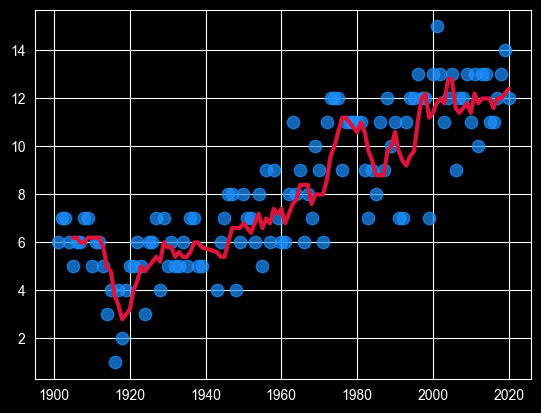

In [237]:
moving_average = prize_per_year.rolling(window=5).mean()

plt.scatter(
  x = prize_per_year.index,
  y = prize_per_year.values,
  c = 'dodgerblue',
  alpha = 0.7,
  s = 80,
)

plt.plot(
  prize_per_year.index,
  moving_average.values,
  c = 'crimson',
  linewidth = 3,
)

plt.show()

# Challenge 1

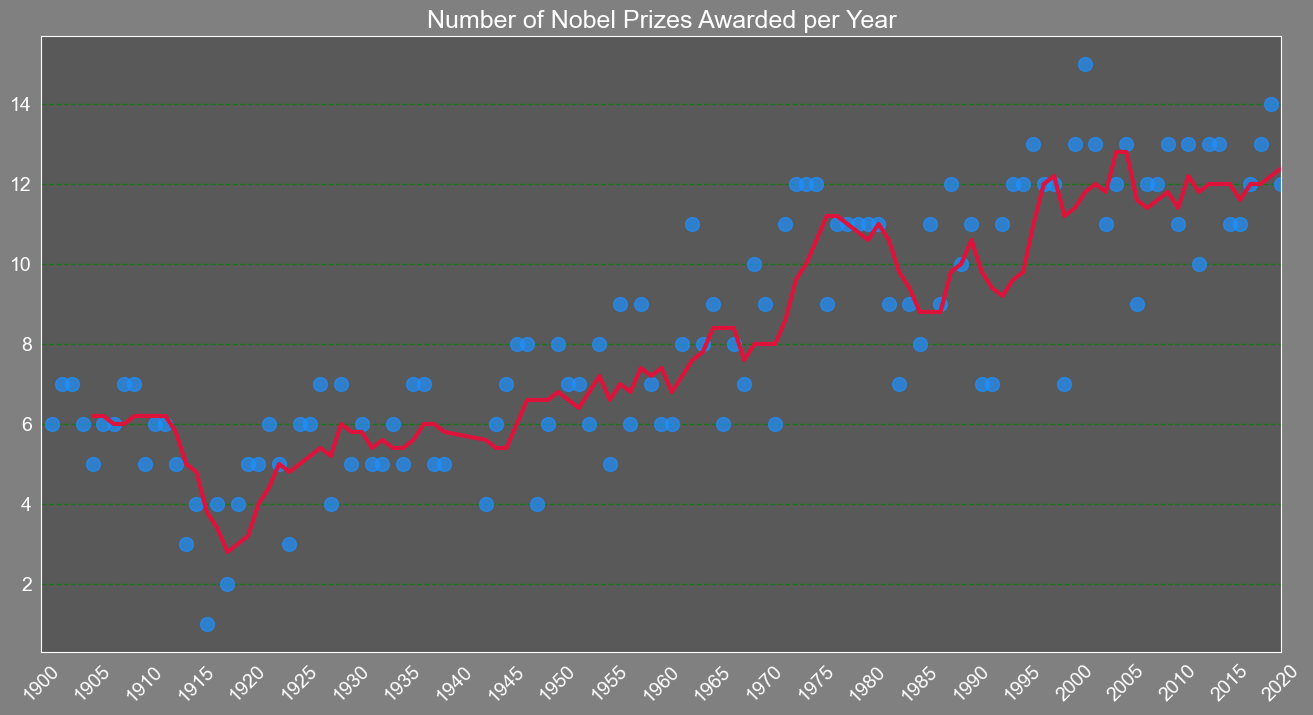

In [238]:
prize_per_year = df_data.groupby(by='year').count().prize
moving_average = prize_per_year.rolling(window=5).mean()

plt.figure(figsize=(16,8), dpi=100, facecolor='gray')
plt.title('Number of Nobel Prizes Awarded per Year', fontsize=18)
plt.yticks(fontsize=14)
plt.grid(visible=False)

plt.xticks(ticks=pd.date_range(start='1900', end='2020', freq='5YS'),
           labels=np.arange(1900, 2021, step=5),
           fontsize=14,
           rotation=45)

ax = plt.gca() # get current axis
ax.set_xlim(pd.to_datetime('1900'), pd.to_datetime('2020'))
ax.set_facecolor(color=(0.35, 0.35, 0.35))
ax.grid(visible=True, alpha=0.7, axis='y', linewidth=1, color='g', linestyle='--')

ax.scatter(x=prize_per_year.index,
           y=prize_per_year.values,
           c='dodgerblue',
           alpha=0.7,
           s=100,
           )

ax.plot(prize_per_year.index,
        moving_average.values,
        c='crimson',
        linewidth=3,
       )
plt.show()

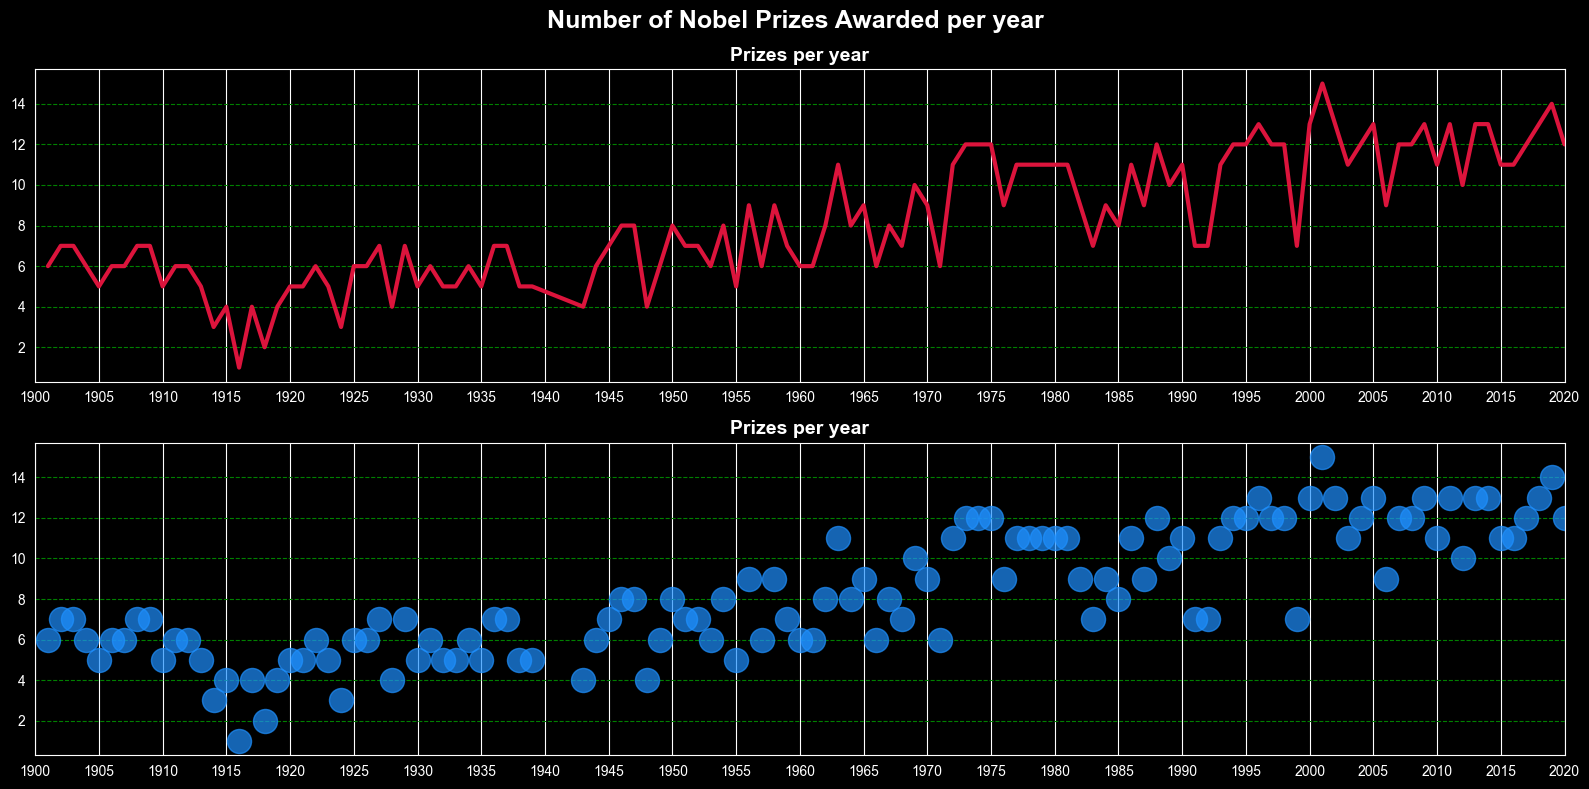

In [239]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 8), dpi=100)
fig.suptitle(t='Number of Nobel Prizes Awarded per year', fontsize=18, fontweight='bold')

# plt.grid(visible=False)
plt.xticks(ticks=np.arange(1900,2021, 5))
ticks=pd.date_range(start='1900', end='2020', freq='5YS')

axes[0].set_title('Prizes per year', fontweight='bold', fontsize=14)
axes[0].set_xlim(pd.to_datetime('1900'), pd.to_datetime('2020'))
axes[0].set_xticks(ticks=ticks, labels=np.arange(1900, 2021, 5))

axes[0].plot(prize_per_year.index, prize_per_year.values,
             c='crimson',
             linewidth=3,)
axes[0].grid(visible=True, axis='y', color='g', linestyle='--')

axes[1].set_title('Prizes per year', fontweight='bold', fontsize=14)
axes[1].scatter(x=prize_per_year.index, y=prize_per_year.values,
                c='dodgerblue',
                alpha=0.7,
                s=300,)
axes[1].set_xlim(pd.to_datetime('1900'), pd.to_datetime('2020'))
axes[1].set_xticks(ticks=ticks, labels=np.arange(1900, 2021, 5))
axes[1].grid(visible=True, axis='y', color='g', linestyle='--')

fig.tight_layout()
plt.show()


# Challenge 2

In [240]:
df_data.head(n=3)
prize_sharing_ = (df_data.groupby('year')
                 .aggregate(func={'share_pct': pd.Series.mean}))
prize_sharing = df_data.groupby(by='year')['share_pct'].mean()
df_data.loc[df_data['year']=='1905-01-01']
df_data.iloc[20:31]

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
20,1904-01-01,Chemistry,The Nobel Prize in Chemistry 1904,"""in recognition of his services in the discove...",1/1,Individual,Sir William Ramsay,1852-10-02,Glasgow,Scotland,United Kingdom,Male,University College London,London,United Kingdom,GBR,100.00
21,1904-01-01,Literature,The Nobel Prize in Literature 1904,"""in recognition of the fresh originality and t...",1/2,Individual,Frédéric Mistral,1830-09-08,Maillane,France,France,Male,NaN,NaN,NaN,FRA,50.00
22,1904-01-01,Literature,The Nobel Prize in Literature 1904,"""in recognition of the numerous and brilliant ...",1/2,Individual,José Echegaray y Eizaguirre,1832-04-19,Madrid,Spain,Spain,Male,NaN,NaN,NaN,ESP,50.00
23,1904-01-01,Medicine,The Nobel Prize in Physiology or Medicine 1904,"""in recognition of his work on the physiology ...",1/1,Individual,Ivan Petrovich Pavlov,1849-09-14,Ryazan,Russia,Russia,Male,Military Medical Academy,St. Petersburg,Russia,RUS,100.00
24,1904-01-01,Peace,The Nobel Peace Prize 1904,NaN,1/1,Organization,Institut de droit international (Institute of ...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.00
25,1904-01-01,Physics,The Nobel Prize in Physics 1904,"""for his investigations of the densities of th...",1/1,Individual,Lord Rayleigh (John William Strutt),1842-11-12,"Langford Grove, Maldon, Essex",United Kingdom,United Kingdom,Male,Royal Institution of Great Britain,London,United Kingdom,GBR,100.00
26,1905-01-01,Chemistry,The Nobel Prize in Chemistry 1905,"""in recognition of his services in the advance...",1/1,Individual,Johann Friedrich Wilhelm Adolf von Baeyer,1835-10-31,Berlin,Prussia (Germany),Germany,Male,Munich University,Munich,Germany,DEU,100.00
27,1905-01-01,Literature,The Nobel Prize in Literature 1905,"""because of his outstanding merits as an epic ...",1/1,Individual,Henryk Sienkiewicz,1846-05-05,Wola Okrzejska,Poland,Poland,Male,NaN,NaN,NaN,POL,100.00
28,1905-01-01,Medicine,The Nobel Prize in Physiology or Medicine 1905,"""for his investigations and discoveries in rel...",1/1,Individual,Robert Koch,1843-12-11,Clausthal (Clausthal-Zellerfeld),Germany,Germany,Male,Institute for Infectious Diseases,Berlin,Germany,DEU,100.00
29,1905-01-01,Peace,The Nobel Peace Prize 1905,NaN,1/1,Individual,"Baroness Bertha Sophie Felicita von Suttner, n...",1843-06-09,Prague,Austrian Empire (Czech Republic),Czech Republic,Female,NaN,NaN,NaN,CZE,100.00


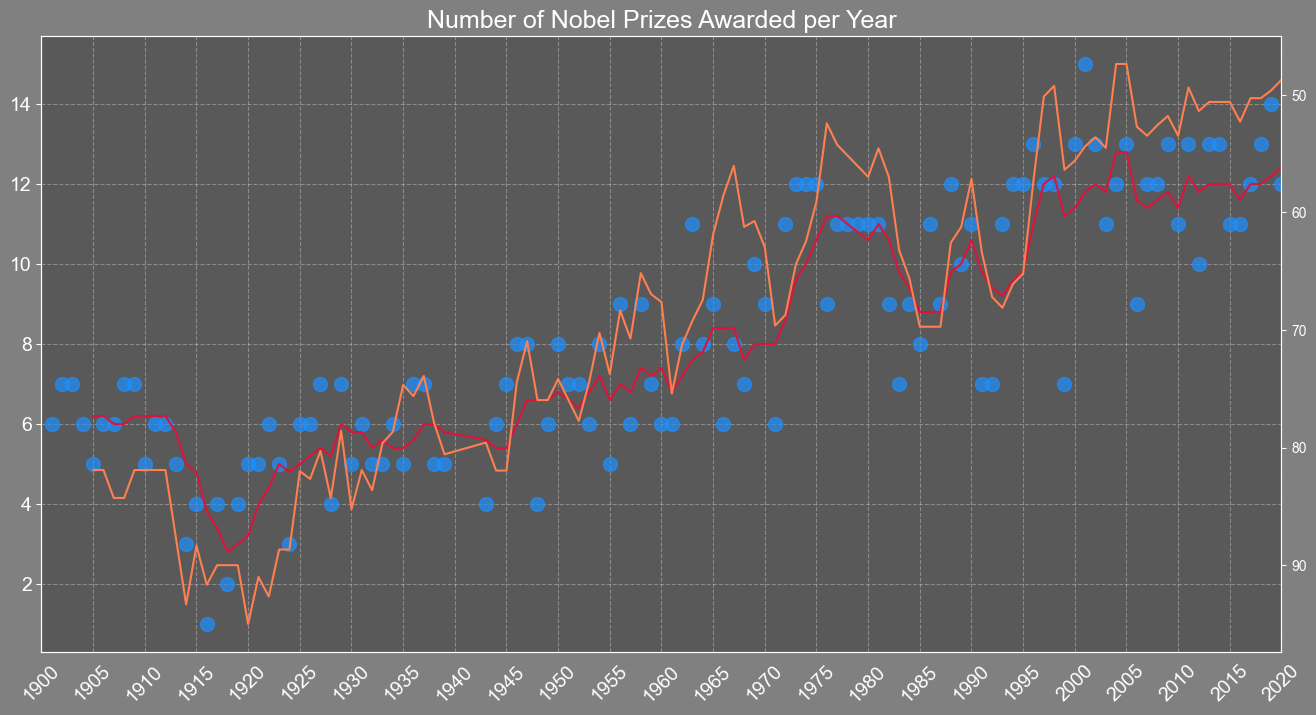

In [241]:
prize_per_year = df_data.groupby(by='year').count().prize
moving_average = prize_per_year.rolling(window=5).mean()
prize_sharing = (df_data.groupby(by='year')['share_pct'].
                 mean().rolling(window=5).mean())

plt.figure(figsize=(16,8), dpi=100, facecolor='gray')
plt.grid(visible=True, alpha=0.3, linestyle='--')
plt.title('Number of Nobel Prizes Awarded per Year', fontsize=18)
plt.yticks(fontsize=14)

plt.xticks(ticks=pd.date_range(start='1900', end='2020', freq='5YS'),
           labels=np.arange(1900, 2021, step=5),
           fontsize=14,
           rotation=45)

ax = plt.gca() # get current axis
ax.set_xlim(pd.to_datetime('1900'), pd.to_datetime('2020'))
ax.set_facecolor(color=(0.35, 0.35, 0.35))
# ax.grid(visible=True, alpha=0.3, axis='y', linewidth=1, color='red', linestyle='--')

ax.scatter(x=prize_per_year.index,
           y=prize_per_year.values,
           c='dodgerblue',
           alpha=0.7,
           s=100,
           label='prize per year scatter')

ax.plot(prize_per_year.index,
        moving_average.values,
        c='crimson',
        linewidth=1.5,
        label='prize per year plot')

ax2 = ax.twinx()
ax2.grid(visible=False)
# ax2.grid(visible=True, alpha=0.3, axis='y', linewidth=1, color='coral', linestyle='--')
ax2.plot(prize_sharing.index,
         prize_sharing.values,
         c='coral',
         linewidth=1.5,
         label='prize sharing')
ax2.invert_yaxis()
plt.show()

In [242]:
yearly_avg_share = df_data.groupby(by='year').agg({'share_pct': pd.Series.mean})
share_moving_average = yearly_avg_share.rolling(window=5).mean()



# Are More Prizes Shared Than Before?

**Challenge**: Investigate if more prizes are shared than before. 

* Calculate the average prize share of the winners on a year by year basis.
* Calculate the 5 year rolling average of the percentage share.
* Copy-paste the cell from the chart you created above.
* Modify the code to add a secondary axis to your Matplotlib chart.
* Plot the rolling average of the prize share on this chart. 
* See if you can invert the secondary y-axis to make the relationship even more clear. 

In [243]:
median_per_year = df_data.groupby(by='year')['share_pct'].mean()
median_per_year

year
1901-01-01    83.33
1902-01-01    71.43
1903-01-01    71.43
1904-01-01    83.33
1905-01-01   100.00
              ...  
2016-01-01    54.55
2017-01-01    50.00
2018-01-01    46.15
2019-01-01    42.86
2020-01-01    50.00
Name: share_pct, Length: 117, dtype: float64

In [244]:
median_per_5years = median_per_year.rolling(window=5).mean()
median_per_5years.info()

<class 'pandas.Series'>
DatetimeIndex: 117 entries, 1901-01-01 to 2020-01-01
Series name: share_pct
Non-Null Count  Dtype  
--------------  -----  
113 non-null    float64
dtypes: float64(1)
memory usage: 1.8 KB


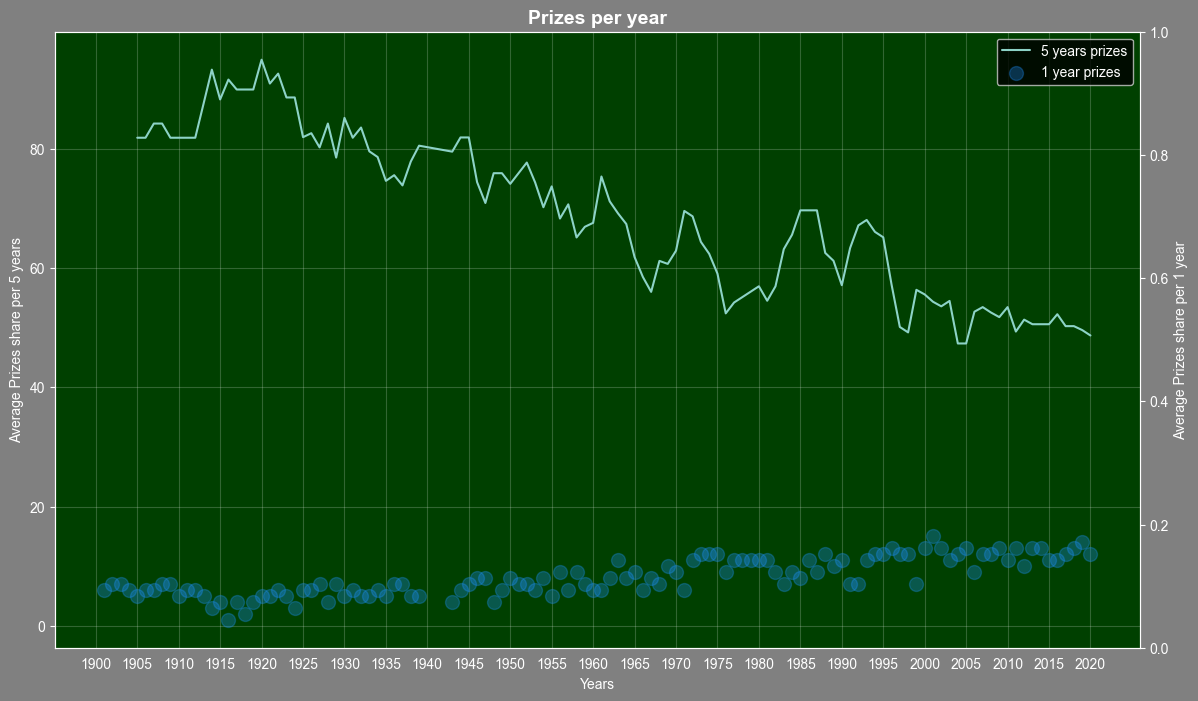

In [245]:
median_per_year = df_data.groupby(by='year')['share_pct'].mean()
median_per_5years = median_per_year.rolling(window=5).mean()

plt.figure(figsize=(14, 8), dpi=100, facecolor='gray')
plt.title('Prizes per year', fontweight='bold', fontsize=14)

plt.plot(median_per_5years.index, median_per_5years.values, label='5 years prizes')

plt.scatter(x=prize_per_year.index, y=prize_per_year.values,
                label='1 year prizes',
                c='dodgerblue',
                alpha=0.3,
                s=100,)

ax1 = plt.gca()
ax1.set_xlabel('Years')
ax1.set_ylabel('Average Prizes share per 5 years')
ax1.set_label('5 years')
ax1.grid(visible=True, alpha=0.2)

ax2 = ax1.twinx()
ax2.set_ylabel('Average Prizes share per 1 year')
ax2.set_label('1 year')
ax2.grid(visible=True, alpha=0.2)
plt.grid(visible=False)

ax1.legend()
ticks = pd.date_range(start='1900', end='2020', freq='5YS')
ax1.set_xticks(ticks=ticks, labels=np.arange(1900, 2021, 5))
ax1.set_facecolor(color=(0.0, 0.25, 0.0))
plt.show()


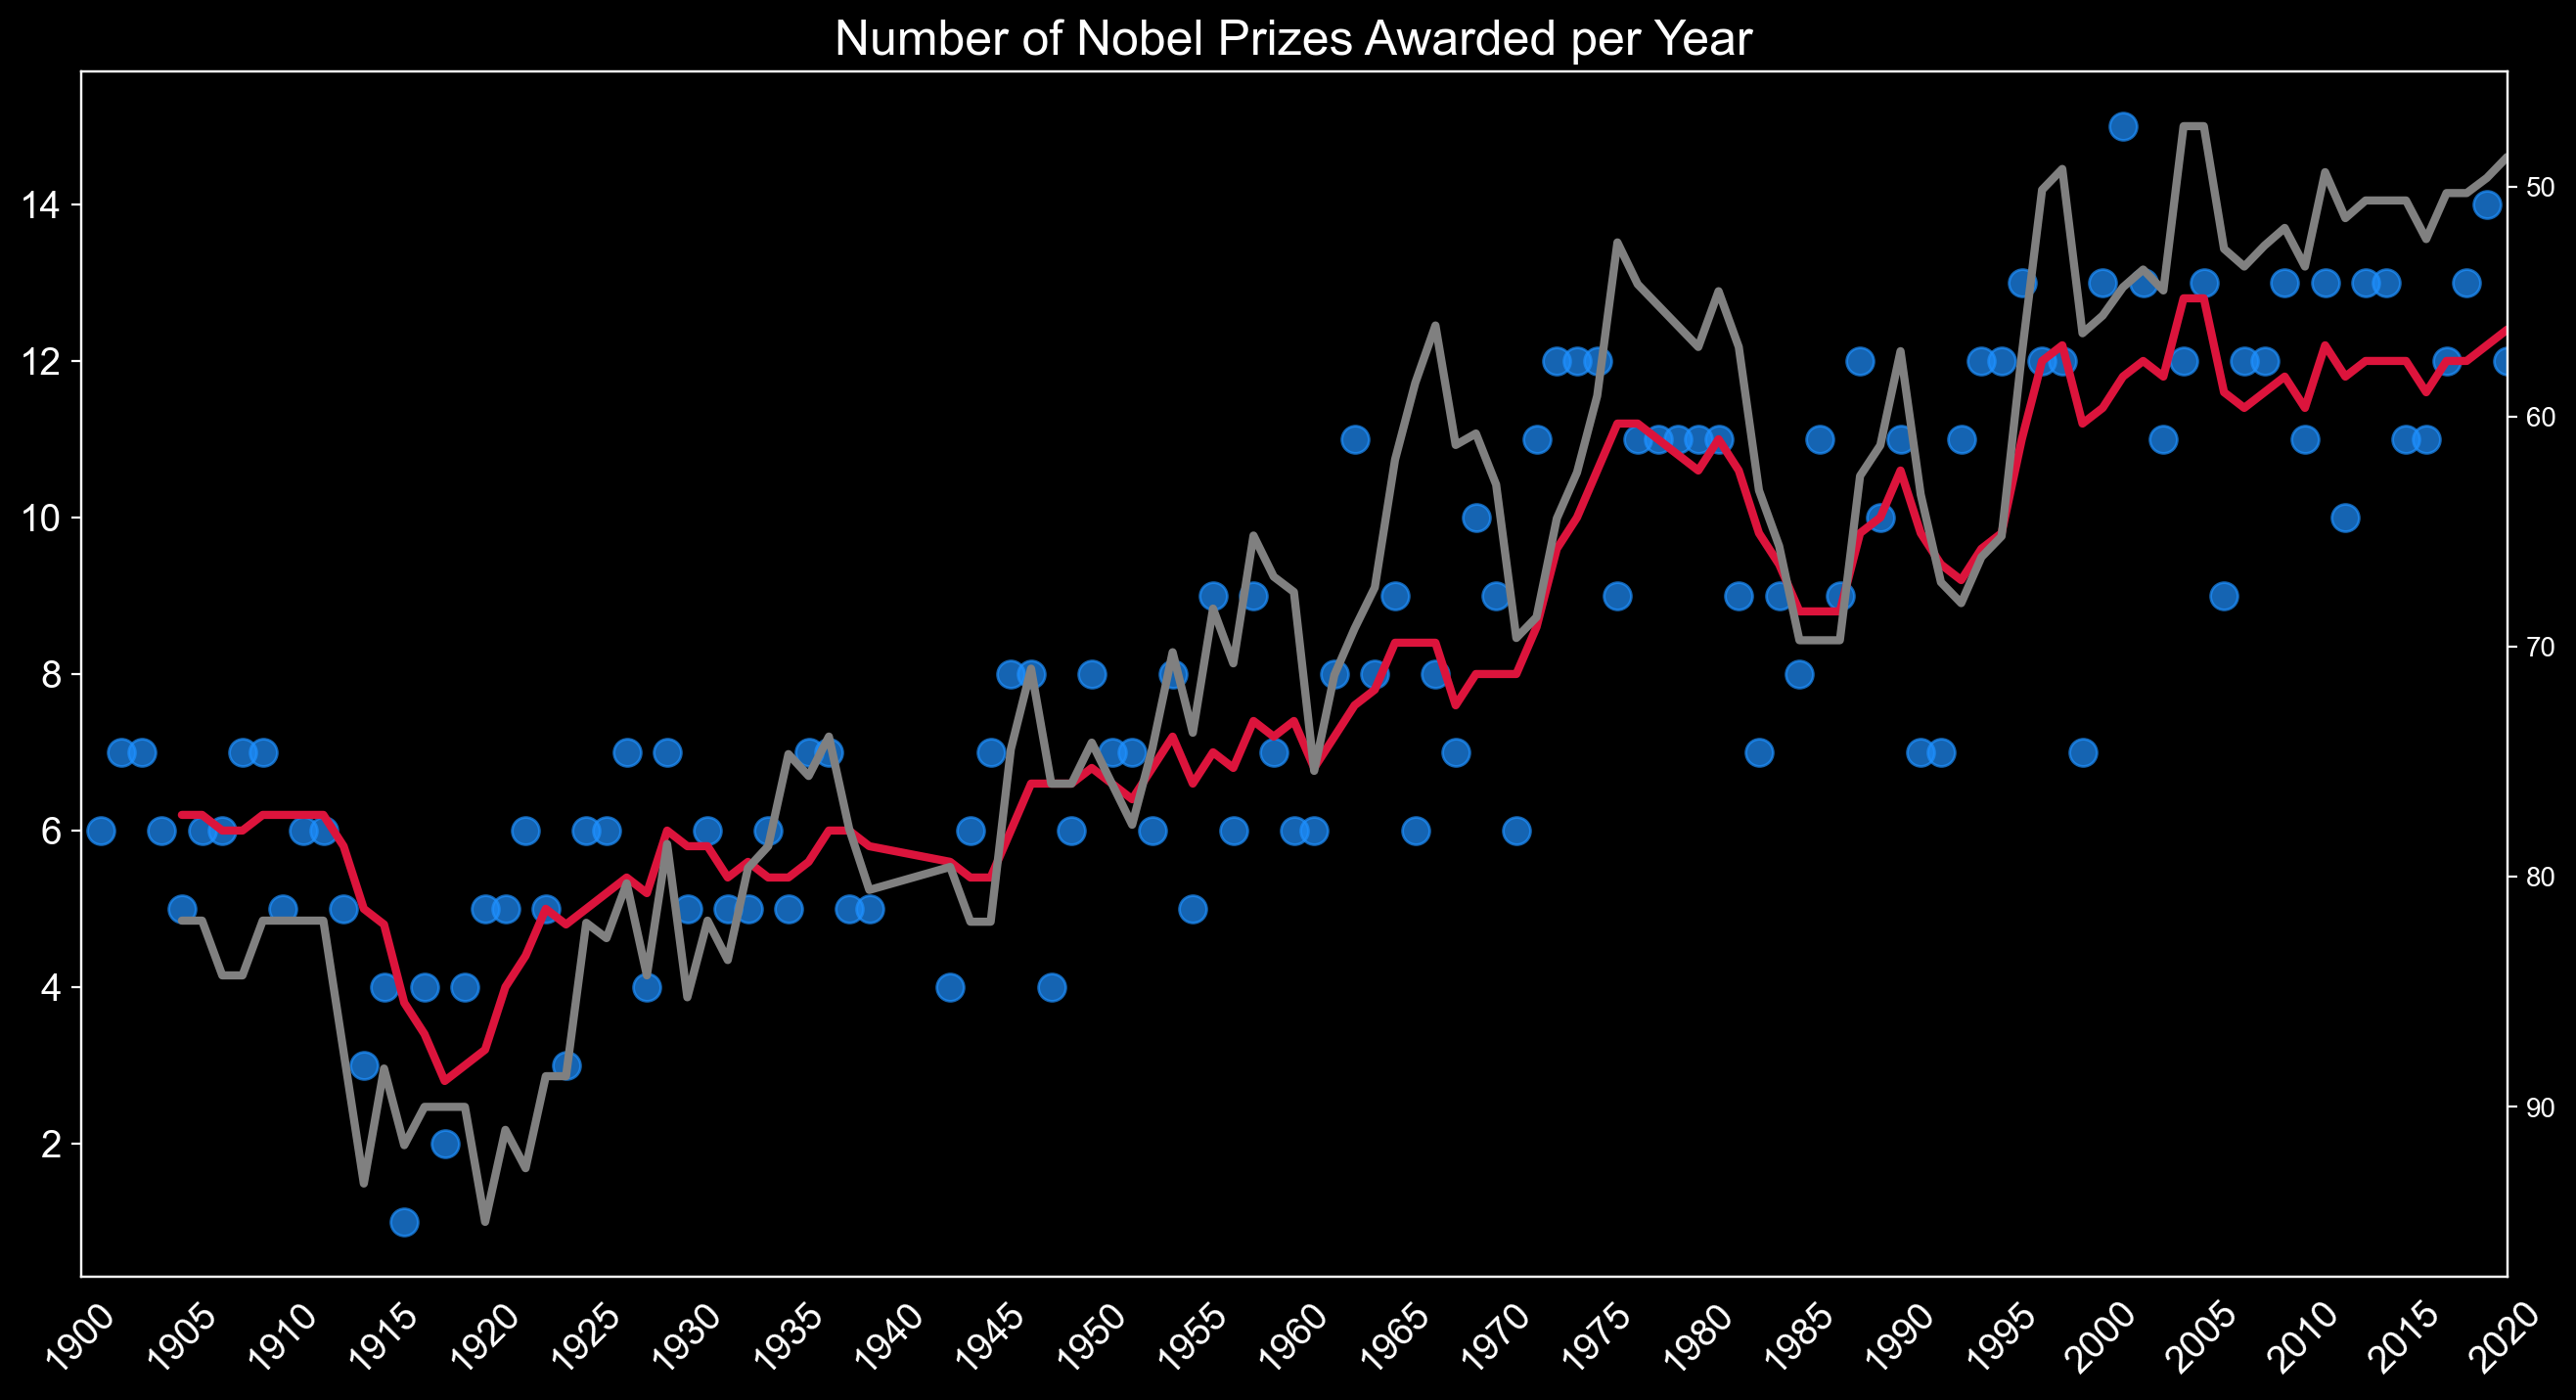

In [246]:
yearly_avg_share = df_data.groupby(by='year')['share_pct'].mean()
share_moving_average = yearly_avg_share.rolling(window=5).mean()

plt.figure(figsize=(16,8), dpi=200)
plt.title('Number of Nobel Prizes Awarded per Year', fontsize=18)
plt.grid(visible=False)
plt.yticks(fontsize=14)
plt.xticks(ticks=pd.date_range(start='1900', end='2020', freq='5YS'),
           labels=np.arange(1900, 2021, step=5),
           fontsize=14,
           rotation=45)

ax1 = plt.gca()
ax2 = ax1.twinx() # create second y-axis
ax2.grid(visible=False)
ax1.set_xlim(pd.to_datetime('1900'), pd.to_datetime('2020'))

ax1.scatter(x=prize_per_year.index,
           y=prize_per_year.values,
           c='dodgerblue',
           alpha=0.7,
           s=100,)

ax1.plot(prize_per_year.index,
        moving_average.values,
        c='crimson',
        linewidth=3,)

# Adding prize share plot on second axis
ax2.plot(prize_per_year.index,
        share_moving_average.values,
        c='grey',
        linewidth=3,)
ax2.invert_yaxis()

plt.show()

# The Countries with the Most Nobel Prizes

**Challenge**: 
* Create a Pandas DataFrame called `top20_countries` that has the two columns. The `prize` column should contain the total number of prizes won. 

<img src=https://i.imgur.com/6HM8rfB.png width=350>

* Is it best to use `birth_country`, `birth_country_current` or `organization_country`? 
* What are some potential problems when using `birth_country` or any of the others? Which column is the least problematic? 
* Then use plotly to create a horizontal bar chart showing the number of prizes won by each country. Here's what you're after:

<img src=https://i.imgur.com/agcJdRS.png width=750>

* What is the ranking for the top 20 countries in terms of the number of prizes?

In [247]:
df_data.isna().values.any()
df_data.head(n=3)

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
0,1901-01-01,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Netherlands,Male,Berlin University,Berlin,Germany,NLD,100.00
1,1901-01-01,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,Individual,Sully Prudhomme,1839-03-16,Paris,France,France,Male,NaN,NaN,NaN,FRA,100.00
2,1901-01-01,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Poland,Male,Marburg University,Marburg,Germany,POL,100.00


In [248]:
col_list = ['birth_city', 'birth_country', 'birth_country_current', 'organization_country']
bcc = df_data['birth_country_current'].isna().value_counts()
bcity = df_data['birth_city'].isna().value_counts()
bcountry = df_data['birth_country'].isna().value_counts()
df_data.loc[df_data.birth_country.isna()==True][col_list]
df_data['organization_country'].isna().value_counts()
print(f"Bcity NaN:{bcity}, Bcc NaN:{bcc}, Bcountry NaN:{bcountry}")

Bcity NaN:birth_city
False    931
True      31
Name: count, dtype: int64, Bcc NaN:birth_country_current
False    934
True      28
Name: count, dtype: int64, Bcountry NaN:birth_country
False    934
True      28
Name: count, dtype: int64


In [269]:
top20_countries = (df_data.groupby(by='birth_country_current', as_index=False)
[['birth_country_current', 'prize']].aggregate(func={'prize': pd.Series.count}).sort_values(by='prize', ascending=False).iloc[:20])
print(type(top20_countries))
top20_countries.head(n=2)
top20_countries

<class 'pandas.DataFrame'>


,birth_country_current,prize
74,United States of America,281
73,United Kingdom,105
26,Germany,84
25,France,57
67,Sweden,29
57,Poland,27
40,Japan,27
61,Russia,26
11,Canada,20
39,Italy,19


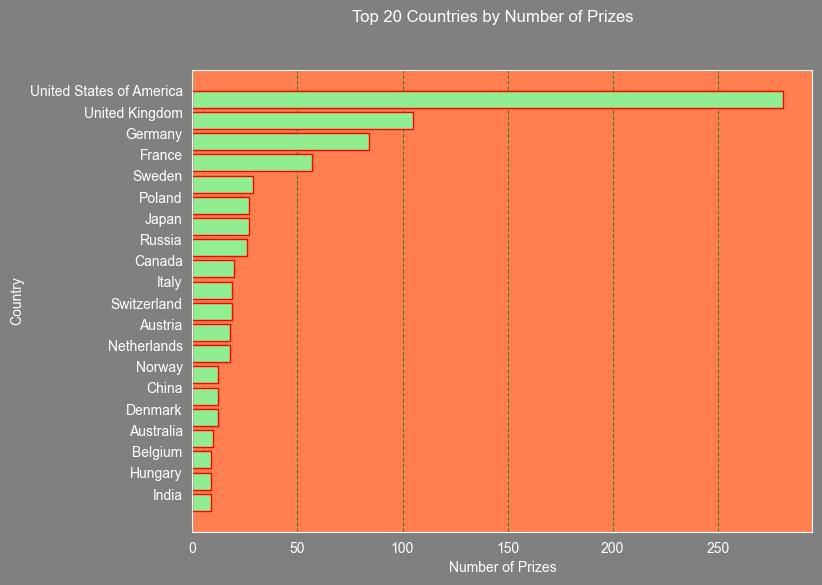

In [270]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=100, facecolor='grey')
plt.grid(visible=False)

ax.barh(y=top20_countries.birth_country_current, width=top20_countries.prize,
        align="edge", color='lightgreen', edgecolor='red')
fig.suptitle(t='Top 20 Countries by Number of Prizes')
ax.set_xlabel('Number of Prizes')
ax.set_ylabel('Country')
ax.set_yticks(ticks=top20_countries.birth_country_current,
               labels=top20_countries.birth_country_current, rotation=0)
ax.set_facecolor(color='coral')
ax.grid(visible=True, axis='x', alpha=0.7, color='green', linestyle='--')
ax.invert_yaxis()

plt.show()

In [272]:
h_bar = px.bar(x=top20_countries.prize,
               y=top20_countries.birth_country_current,
               orientation='h',
               color=top20_countries.prize,
               color_continuous_scale='Viridis',
               title='Top 20 Countries by Number of Prizes')

h_bar.update_layout(xaxis_title='Number of Prizes',
                    yaxis_title='Country',
                    coloraxis_showscale=False)
h_bar.update_yaxes(autorange="reversed")
h_bar.show()

# Use a Choropleth Map to Show the Number of Prizes Won by Country

* Create this choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/):

<img src=https://i.imgur.com/s4lqYZH.png>
<img src="./image_4.png">
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map. 

Hint: You'll need to use a 3 letter country code for each country. 


In [258]:
df = px.data.gapminder().query("year==2007")


,country,iso_alpha
71,Australia,AUS
83,Austria,AUT
119,Belgium,BEL
251,Canada,CAN
299,China,CHN
419,Denmark,DNK
539,France,FRA
575,Germany,DEU
683,Hungary,HUN
707,India,IND


In [259]:
cs_list = [_ for _ in top20_countries.birth_country_current]
iso = df[['country', 'iso_alpha']].query("country == @cs_list")
iso_dict = {_[0]: _[1] for _ in zip(iso.country.values, iso.iso_alpha.values)}
iso_dict['Russia'] = 'RUS'
iso_dict['United States of America'] = 'USA'
top20_countries['iso_alpha'] = top20_countries['birth_country_current']
top20_countries['iso_alpha'] = top20_countries['iso_alpha'].map(iso_dict, 'ignore')
top20_countries.loc[top20_countries['iso_alpha'].isna()]
top20_countries.loc[top20_countries['birth_country_current'] == 'United States of America', 'iso_alpha'] = 'USA'

In [262]:
top20_countries.rename(columns={'birth_country_current': 'country'}, inplace=True)
top20_countries.sample(n=3)

,country,prize,iso_alpha
33,India,9,IND
40,Japan,27,JPN
57,Poland,27,POL


In [263]:
import plotly.express as px

fig = px.choropleth(top20_countries, locations="iso_alpha",
                    color="prize", # lifeExp is a column of gapminder
                    hover_name="country", # column to add to hover information
                    color_continuous_scale=px.colors.sequential.Hot)
fig.show()

In [274]:
df_countries = df_data.groupby(['birth_country_current', 'ISO'],
                               as_index=False).agg({'prize': pd.Series.count})
df_countries.sort_values('prize', ascending=False)

,birth_country_current,ISO,prize
74,United States of America,USA,281
73,United Kingdom,GBR,105
26,Germany,DEU,84
25,France,FRA,57
67,Sweden,SWE,29
...,...,...,...
63,Slovakia,SVK,1
75,Venezuela,VEN,1
76,Vietnam,VNM,1
77,Yemen,YEM,1


In [275]:
world_map = px.choropleth(df_countries,
                          locations='ISO',
                          color='prize',
                          hover_name='birth_country_current',
                          color_continuous_scale=px.colors.sequential.matter)

world_map.update_layout(coloraxis_showscale=True,)

world_map.show()

# In Which Categories are the Different Countries Winning Prizes? 

**Challenge**: See if you can divide up the plotly bar chart you created above to show the which categories made up the total number of prizes. Here's what you're aiming for:

<img src=https://i.imgur.com/iGaIKCL.png>
<img src="./image_5.png">
* In which category are Germany and Japan the weakest compared to the United States?
* In which category does Germany have more prizes than the UK?
* In which categories does France have more prizes than Germany?
* Which category makes up most of Australia's nobel prizes?
* Which category makes up half of the prizes in the Netherlands?
* Does the United States have more prizes in Economics than all of France? What about in Physics or Medicine?


The hard part is preparing the data for this chart! 


*Hint*: Take a two-step approach. The first step is grouping the data by country and category. Then you can create a DataFrame that looks something like this:

<img src=https://i.imgur.com/VKjzKa1.png width=450>


In [ ]:
df_data.sample(n=1)

In [276]:
crazy_barh = df_data.groupby(by=['birth_country_current', 'category'], as_index=False).aggregate(func={'prize': pd.Series.count}).sort_values(by='prize', ascending=False).loc[:10]
total_prizes = df_data.groupby(by='birth_country_current')['prize'].count()
# crazy_barh['total_prizes']
crazy_barh['total_prize'] = crazy_barh['birth_country_current']
dict_tp = {v: int(k) for v, k in zip(total_prizes.index, total_prizes.values)}
crazy_barh['total_prize'] = crazy_barh['total_prize'].map(func=dict_tp)
crazy_barh.sort_values(by='birth_country_current')

,birth_country_current,category,prize,total_prize
5,Australia,Medicine,7,10
10,Austria,Medicine,6,18
32,Canada,Physics,6,20
65,France,Chemistry,10,57
70,France,Physics,10,57
67,France,Literature,11,57
68,France,Medicine,12,57
69,France,Peace,10,57
76,Germany,Physics,26,84
74,Germany,Medicine,18,84


In [277]:
# fig.add_choroplethmap()
fig = px.bar(x=crazy_barh.prize, y=crazy_barh.birth_country_current, color=crazy_barh.category,
             orientation='h', title='How many Nobel Prizes awarded for countries per category')
fig.update_yaxes(autorange='reversed')
fig.show()

In [311]:
cat_country = df_data.groupby(['birth_country_current', 'category'],
                               as_index=False).agg({'prize': pd.Series.count})
cat_country.sort_values(by='prize', ascending=False, inplace=True)
top20_countries
cat_country

,birth_country_current,category,prize
204,United States of America,Medicine,78
206,United States of America,Physics,70
201,United States of America,Chemistry,55
202,United States of America,Economics,49
198,United Kingdom,Medicine,28
...,...,...,...
190,Turkey,Chemistry,1
207,Venezuela,Medicine,1
208,Vietnam,Peace,1
209,Yemen,Peace,1


In [288]:
merged_df = pd.merge(cat_country, top20_countries, on='birth_country_current')
merged_df

,birth_country_current,category,prize_x,prize_y
0,United States of America,Medicine,78,281
1,United States of America,Physics,70,281
2,United States of America,Chemistry,55,281
3,United States of America,Economics,49,281
4,United Kingdom,Medicine,28,105
...,...,...,...,...
105,Japan,Peace,1,27
106,Hungary,Literature,1,9
107,Hungary,Economics,1,9
108,Poland,Economics,1,27


In [310]:
merged_df.columns = ['country', 'category', 'cat_prize', 'total_prize']
merged_df.sort_values(by='total_prize', ascending=False, inplace=True)
merged_df_ = merged_df[['country', 'category', 'cat_prize']]
merged_df

,country,category,cat_prize,total_prize
1,United States of America,Physics,70,281
19,United States of America,Literature,10,281
0,United States of America,Medicine,78,281
9,United States of America,Peace,19,281
2,United States of America,Chemistry,55,281
...,...,...,...,...
94,Belgium,Literature,1,9
95,Belgium,Physics,1,9
91,Belgium,Chemistry,1,9
79,India,Economics,2,9


In [309]:
cat_cntry_bar = px.bar(x=merged_df.cat_prize,
                       y=merged_df.country,
                       color=merged_df.category,
                       orientation='h',
                       title='Top 20 Countries by Number of Prizes and Category')

cat_cntry_bar.update_layout(xaxis_title='Number of Prizes',
                            yaxis_title='Country')
cat_cntry_bar.update_yaxes(autorange="reversed")
cat_cntry_bar.show()

### Number of Prizes Won by Each Country Over Time

* When did the United States eclipse every other country in terms of the number of prizes won? 
* Which country or countries were leading previously?
* Calculate the cumulative number of prizes won by each country in every year. Again, use the `birth_country_current` of the winner to calculate this. 
* Create a [plotly line chart](https://plotly.com/python/line-charts/) where each country is a coloured line. 

In [ ]:
df_data.head(n=1)

In [ ]:
# cumulative country prizez per year
ccppy = df_data.groupby(by=['birth_country_current', 'year' ], as_index=False)['prize'].count()
ccppy = ccppy.sort_values(by='year')[['year', 'birth_country_current', 'prize']]
ccppy

In [ ]:
new_ccppy = ccppy.groupby(by=['birth_country_current', 'year']).sum().groupby(level=0).cumsum()
new_ccppy_r = ccppy.groupby(by=[ 'year', 'birth_country_current']).sum().groupby(level=0).cumsum()
new_ccppy_r # order of grouping by has matter, you can see in it column order in DataFrame / Series
new_ccppy.index # Here you have multiindex, and you have reset it to get cleaner data

In [ ]:
new_ccppy.reset_index(inplace=True)
new_ccppy

In [ ]:
fig = px.line(new_ccppy, x='year', y='prize', color='birth_country_current',
              title='Prizes won by each country per year ')
fig.show()

In [ ]:
prize_by_year = df_data.groupby(by=['birth_country_current', 'year'], as_index=False).count()
prize_by_year = prize_by_year.sort_values(by='year')[['year', 'birth_country_current', 'prize']]
prize_by_year

In [ ]:
cumulative_prizes = prize_by_year.groupby(by=['birth_country_current', 'year']).sum().groupby(level=0).cumsum()
cumulative_prizes.reset_index(inplace=True)
cumulative_prizes

In [312]:
l_chart = px.line(cumulative_prizes,
                  x='year',
                  y='prize',
                  color='birth_country_current',
                  hover_name='birth_country_current')

l_chart.update_layout(xaxis_title='Year',
                      yaxis_title='Number of Prizes')

l_chart.show()

# What are the Top Research Organisations?

**Challenge**: Create a bar chart showing the organisations affiliated with the Nobel laureates. It should looks something like this:

<img src=https://i.imgur.com/zZihj2p.png width=600>
<img src="./image_7.png" width=600>
* Which organisations make up the top 20?
* How many Nobel prize winners are affiliated with the University of Chicago and Harvard University?

# Which Cities Make the Most Discoveries? 

Where do major discoveries take place?  

**Challenge**: 
* Create another plotly bar chart graphing the top 20 organisation cities of the research institutions associated with a Nobel laureate. 
* Where is the number one hotspot for discoveries in the world?
* Which city in Europe has had the most discoveries?

# Where are Nobel Laureates Born? Chart the Laureate Birth Cities 

**Challenge**: 
* Create a plotly bar chart graphing the top 20 birth cities of Nobel laureates. 
* Use a named colour scale called `Plasma` for the chart.
* What percentage of the United States prizes came from Nobel laureates born in New York? 
* How many Nobel laureates were born in London, Paris and Vienna? 
* Out of the top 5 cities, how many are in the United States?


# Plotly Sunburst Chart: Combine Country, City, and Organisation

**Challenge**: 

* Create a DataFrame that groups the number of prizes by organisation. 
* Then use the [plotly documentation to create a sunburst chart](https://plotly.com/python/sunburst-charts/)
* Click around in your chart, what do you notice about Germany and France? 


Here's what you're aiming for:

<img src=https://i.imgur.com/cemX4m5.png width=300>



# Patterns in the Laureate Age at the Time of the Award

How Old Are the Laureates When the Win the Prize?

**Challenge**: Calculate the age of the laureate in the year of the ceremony and add this as a column called `winning_age` to the `df_data` DataFrame. Hint: you can use [this](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.dt.html) to help you. 



### Who were the oldest and youngest winners?

**Challenge**: 
* What are the names of the youngest and oldest Nobel laureate? 
* What did they win the prize for?
* What is the average age of a winner?
* 75% of laureates are younger than what age when they receive the prize?
* Use Seaborn to [create histogram](https://seaborn.pydata.org/generated/seaborn.histplot.html) to visualise the distribution of laureate age at the time of winning. Experiment with the number of `bins` to see how the visualisation changes.

### Descriptive Statistics for the Laureate Age at Time of Award

* Calculate the descriptive statistics for the age at the time of the award. 
* Then visualise the distribution in the form of a histogram using [Seaborn's .histplot() function](https://seaborn.pydata.org/generated/seaborn.histplot.html).
* Experiment with the `bin` size. Try 10, 20, 30, and 50.  

### Age at Time of Award throughout History

Are Nobel laureates being nominated later in life than before? Have the ages of laureates at the time of the award increased or decreased over time?

**Challenge**

* Use Seaborn to [create a .regplot](https://seaborn.pydata.org/generated/seaborn.regplot.html?highlight=regplot#seaborn.regplot) with a trendline.
* Set the `lowess` parameter to `True` to show a moving average of the linear fit.
* According to the best fit line, how old were Nobel laureates in the years 1900-1940 when they were awarded the prize?
* According to the best fit line, what age would it predict for a Nobel laureate in 2020?


### Winning Age Across the Nobel Prize Categories

How does the age of laureates vary by category? 

* Use Seaborn's [`.boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html?highlight=boxplot#seaborn.boxplot) to show how the mean, quartiles, max, and minimum values vary across categories. Which category has the longest "whiskers"? 
* In which prize category are the average winners the oldest?
* In which prize category are the average winners the youngest?

**Challenge**
* Now use Seaborn's [`.lmplot()`](https://seaborn.pydata.org/generated/seaborn.lmplot.html?highlight=lmplot#seaborn.lmplot) and the `row` parameter to create 6 separate charts for each prize category. Again set `lowess` to `True`.
* What are the winning age trends in each category? 
* Which category has the age trending up and which category has the age trending down? 
* Is this `.lmplot()` telling a different story from the `.boxplot()`?
* Create another chart with Seaborn. This time use `.lmplot()` to put all 6 categories on the same chart using the `hue` parameter. 
